In [4]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#Load Dataset
df = pd.read_excel('/content/Dataset for Data Analytics.xlsx')

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [6]:
#Check Dataset Information
print(df.shape)

df.info()

(1200, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64

In [8]:
#Check Missing Values
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [9]:
#Fill Missing Values
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')

df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [10]:
#Convert Date Column
df['Date'] = pd.to_datetime(df['Date'])

df['Date'].head()

,Date
0,2023-01-04
1,2024-08-23
2,2024-02-27
3,2023-10-15
4,2025-05-08


In [11]:
#Detect Outliers
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['TotalPrice'] < lower) |
    (df['TotalPrice'] > upper)
]

print("Number of outliers:", len(outliers))

Number of outliers: 8


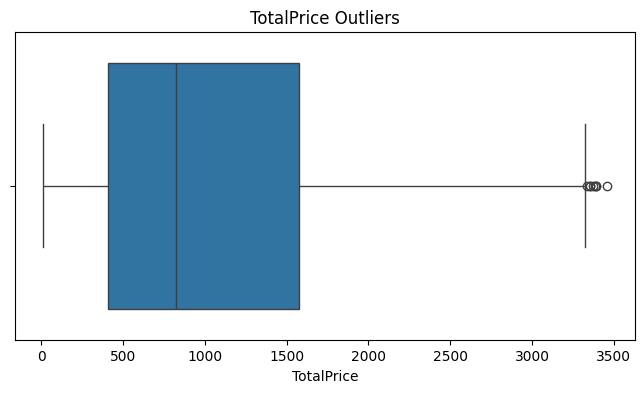

In [12]:
#Visualize Outliers
plt.figure(figsize=(8,4))
sns.boxplot(x=df['TotalPrice'])
plt.title("TotalPrice Outliers")
plt.show()

In [13]:
#Treat Outliers
df['TotalPrice'] = np.clip(
    df['TotalPrice'],
    lower,
    upper
)

In [14]:
#Create New Features
df['OrderMonth'] = df['Date'].dt.month

In [15]:
df['OrderYear'] = df['Date'].dt.year

In [16]:
df['AvgItemValue'] = df['TotalPrice'] / df['Quantity']

In [17]:
df['CartEfficiency'] = df['Quantity'] / df['ItemsInCart']

In [18]:
#Verify New Features
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,OrderMonth,OrderYear,AvgItemValue,CartEfficiency
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,1,2023,570.62,0.714286
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,8,2024,151.35,0.666667
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2,2024,550.68,0.625000
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,10,2023,273.19,0.200000
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,5,2025,626.01,0.500000


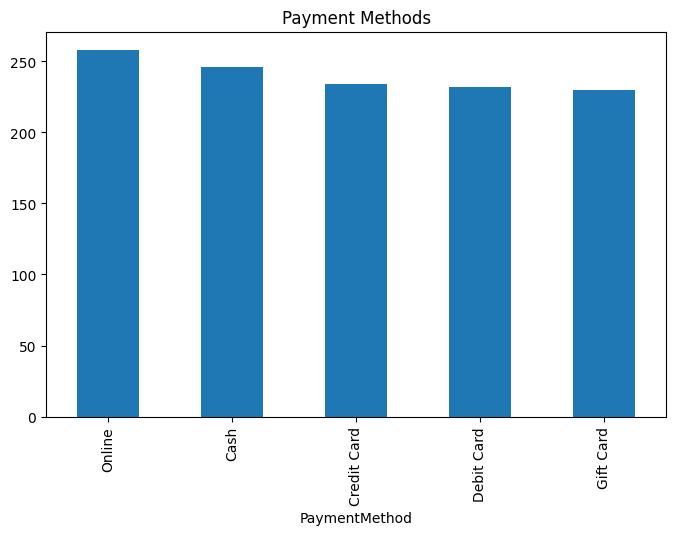

In [19]:
#EDA Charts
plt.figure(figsize=(8,5))
df['PaymentMethod'].value_counts().plot(kind='bar')
plt.title('Payment Methods')
plt.show()

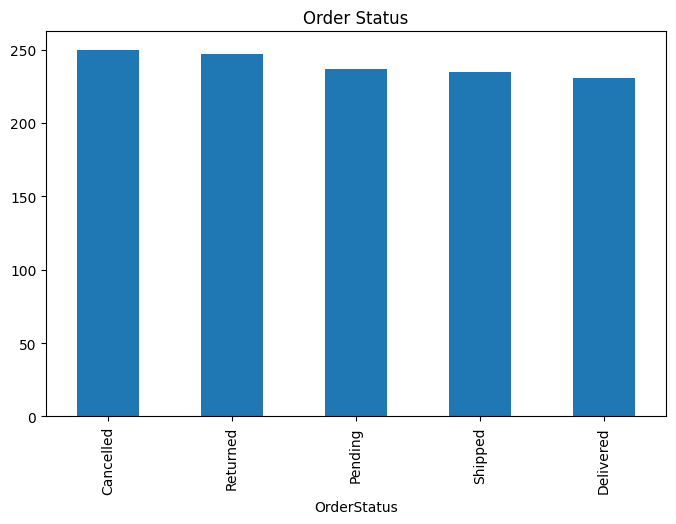

In [20]:
#Order Status Chart
plt.figure(figsize=(8,5))
df['OrderStatus'].value_counts().plot(kind='bar')
plt.title('Order Status')
plt.show()

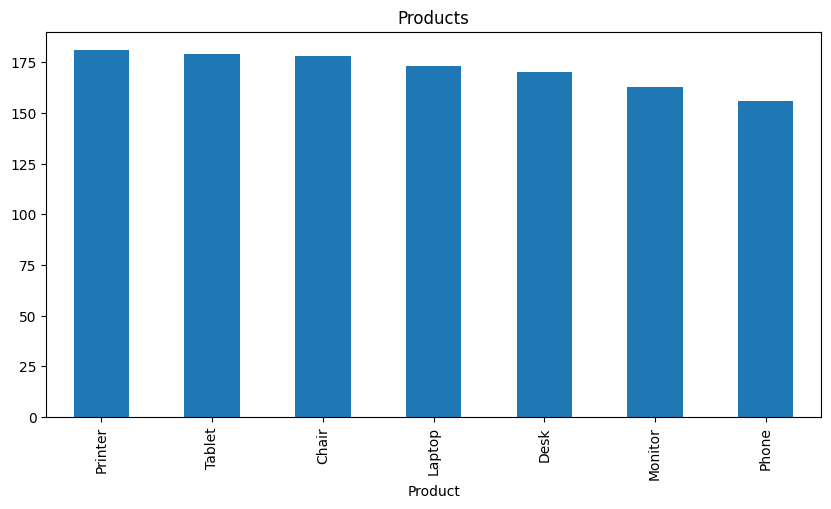

In [21]:
#Product Distribution
plt.figure(figsize=(10,5))
df['Product'].value_counts().plot(kind='bar')
plt.title('Products')
plt.show()

In [22]:
#Save Cleaned Dataset
df.to_csv('Cleaned_Dataset.csv', index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully
